# Project06 · Movie Recommendation AI Advanced
## MovieLens 100K 기반 사용자 개인화 영화 추천 시스템

이 노트북은 Project06(심화)의 전체 연구 과정을 담고 있습니다. Project05(`services/06-movie-recommendation-ai`)가
"영화 한 편을 선택하면 비슷한 영화를 추천"하는 입문 프로젝트였다면, Project06은 **사용자의 평점 이력을 분석해
취향 프로필을 만들고, 이를 바탕으로 개인화 추천을 제공**하는 심화 프로젝트입니다.

다루는 내용:

1. 데이터 로딩 및 품질 검증
2. EDA (사용자별 평점 개수 분포를 특히 상세히 분석)
3. 이상치/왜도 분석
4. 영화 / 사용자 / Interaction Feature Engineering
5. 추천 알고리즘 6종 구현 (Popularity, Content-Based, Item-CF, User-CF, SVD, Hybrid)
6. 추천 알고리즘 평가 및 비교
7. 최종 하이브리드 추천 전략 선정

> 이 노트북은 `ai-server/feature_engineering.py`의 함수를 그대로 가져와 사용합니다. 즉, 이 노트북에서
> 검증한 로직이 운영 코드(`train_model.py`, `recommendation_service.py`)와 100% 동일합니다.

## 1. 라이브러리 불러오기

필요한 라이브러리만 불러옵니다. 경고는 무조건 숨기지 않고, 재현성을 위해 `RANDOM_STATE`를 고정합니다.

In [16]:
import sys
import warnings
from pathlib import Path

import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.metrics.pairwise import cosine_similarity

# ai-server/ 폴더의 feature_engineering.py를 그대로 가져와 사용한다.
# (Notebook과 운영 코드가 동일한 로딩/정제/파생변수 로직을 쓰도록 하기 위함)
sys.path.insert(0, "..")
import feature_engineering as fe

# OS별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

# 기타 Matplotlib 설정
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 판다스 출력 폭 설정 (장르 리스트, 긴 제목이 잘리지 않도록)
pd.set_option("display.max_colwidth", 80)

warnings.filterwarnings("default")  # 경고를 숨기지 않는다 (필요할 때만 개별적으로 무시)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = fe.RANDOM_STATE
np.random.seed(RANDOM_STATE)
print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


## 2. 데이터 경로 설정 및 로딩

Notebook 실행 위치가 달라져도 데이터를 찾을 수 있도록 `pathlib.Path` 기반으로 탐색한다.
데이터가 없으면 명확한 오류 메시지를 출력하고 이후 셀을 실행하지 않도록 안내한다.

In [17]:
DATA_DIR = Path("../data")
data_dir = fe.find_data_dir(DATA_DIR)

if data_dir is None:
    fe.print_missing_data_guide(DATA_DIR)
    raise FileNotFoundError("MovieLens 100K 데이터를 찾을 수 없습니다. 위 안내를 확인하세요.")

print(f"데이터 경로: {data_dir.resolve()}")

ratings_raw = fe.load_ratings(data_dir)
movies_raw = fe.load_movies(data_dir)
users_raw = fe.load_users(data_dir)

print(f"ratings: {ratings_raw.shape}, movies: {movies_raw.shape}, users: {users_raw.shape}")

데이터 경로: C:\dev\AI-Service-Lab\services\07-movie-recommendation-ai-advanced\ai-server\data\ml-100k
ratings: (100000, 4), movies: (1682, 23), users: (943, 5)


ratings: (100000, 4), movies: (1682, 23), users: (943, 5)


## 3. 데이터 구조 확인

각 데이터프레임의 `shape`, `head()`, `info()`, `describe()`, 고유값 수를 확인한다.

In [18]:
ratings_raw.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [19]:
ratings_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int32
 1   movie_id   100000 non-null  int32
 2   rating     100000 non-null  int8 
 3   timestamp  100000 non-null  int64
dtypes: int32(2), int64(1), int8(1)
memory usage: 1.6 MB


In [6]:
ratings_raw.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [20]:
movies_raw.head()

,movie_id,title,release_date,imdb_url,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%20(1995),0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(1995),0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995),0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [8]:
movies_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie_id      1682 non-null   int64 
 1   title         1682 non-null   object
 2   release_date  1681 non-null   object
 3   imdb_url      1679 non-null   object
 4   unknown       1682 non-null   int64 
 5   Action        1682 non-null   int64 
 6   Adventure     1682 non-null   int64 
 7   Animation     1682 non-null   int64 
 8   Children's    1682 non-null   int64 
 9   Comedy        1682 non-null   int64 
 10  Crime         1682 non-null   int64 
 11  Documentary   1682 non-null   int64 
 12  Drama         1682 non-null   int64 
 13  Fantasy       1682 non-null   int64 
 14  Film-Noir     1682 non-null   int64 
 15  Horror        1682 non-null   int64 
 16  Musical       1682 non-null   int64 
 17  Mystery       1682 non-null   int64 
 18  Romance       1682 non-null   int64 
 19  Sci-Fi

In [8]:
users_raw.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [9]:
users_raw.describe()

,user_id,age
count,943.000000,943.000000
mean,472.000000,34.051962
std,272.364951,12.192740
min,1.000000,7.000000
25%,236.500000,25.000000
50%,472.000000,31.000000
75%,707.500000,43.000000
max,943.000000,73.000000


In [21]:
print("고유 사용자 수:", ratings_raw["user_id"].nunique())
print("고유 영화 수(ratings 기준):", ratings_raw["movie_id"].nunique())
print("u.user에 등록된 사용자 수:", users_raw["user_id"].nunique())
print("u.item에 등록된 영화 수:", movies_raw["movie_id"].nunique())

고유 사용자 수: 943
고유 영화 수(ratings 기준): 1682
u.user에 등록된 사용자 수: 943
u.item에 등록된 영화 수: 1682


**확인 결과**: 사용자 943명, 영화 1,682편, 평점 100,000건으로 MovieLens 100K 공식 스펙과 일치한다.
평점이 하나도 없는 영화가 존재할 수 있으므로(`ratings.movie_id.nunique() <= movies.shape[0]`),
영화 Feature를 만들 때 결측(평점 0건)을 명시적으로 처리해야 한다.

## 4. 결측치 분석

In [22]:
print("ratings 결측치\n", ratings_raw.isnull().sum())
print()
print("movies 결측치\n", movies_raw.isnull().sum())
print()
print("users 결측치\n", users_raw.isnull().sum())

ratings 결측치
 user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

movies 결측치
 movie_id        0
title           0
release_date    1
imdb_url        3
unknown         0
Action          0
Adventure       0
Animation       0
Children's      0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

users 결측치
 user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64


`ratings`, `users`에는 결측치가 없다. `movies`의 `release_date`, `imdb_url`에 소수의 결측치가 있을 수 있는데,
이는 IMDb에 등록되지 않았거나 개봉일 정보가 유실된 영화들이다. 두 컬럼 모두 추천 알고리즘에서 직접 사용하지
않으므로(제목에서 연도를 다시 추출) 추천 모델에 미치는 영향은 없다.

## 5. 중복 데이터 분석

In [23]:
print("완전 중복 행(ratings):", ratings_raw.duplicated().sum())
print("(user_id, movie_id) 중복 평가:", ratings_raw.duplicated(subset=["user_id", "movie_id"]).sum())
print("사용자 메타데이터 중복(user_id):", users_raw.duplicated(subset=["user_id"]).sum())
print("영화 메타데이터 중복(movie_id):", movies_raw.duplicated(subset=["movie_id"]).sum())

duplicate_titles = movies_raw["title"].duplicated().sum()
print(f"제목이 중복된 영화: {duplicate_titles}건 (서로 다른 movie_id에 동일 제목이 존재하는 "
      f"MovieLens 100K의 알려진 특성)")

완전 중복 행(ratings): 0
(user_id, movie_id) 중복 평가: 0
사용자 메타데이터 중복(user_id): 0
영화 메타데이터 중복(movie_id): 0
제목이 중복된 영화: 18건 (서로 다른 movie_id에 동일 제목이 존재하는 MovieLens 100K의 알려진 특성)


(user_id, movie_id) 중복 평가나 메타데이터 중복은 없다. 제목이 중복된 영화가 소수 존재하지만
`movie_id`가 서로 다른 별개의 레코드이므로, 병합/유사도 계산 시 `movie_id` 기준으로 처리하면 문제가 없다.
`train_model.py`의 `clean_ratings()`는 혹시 모를 중복·범위 밖 평점을 방어적으로 한 번 더 제거한다.

## 6. 데이터 병합

`ratings`, `movies`, `users`를 하나의 분석용 테이블로 합친다. 병합 전후 행 수를 반드시 검증해
Left Join 과정에서 행이 늘어나거나(다대다 조인 실수) 줄어드는(Inner Join으로 인한 손실) 문제가 없는지 확인한다.

In [24]:
ratings = fe.clean_ratings(ratings_raw)
print(f"정제 후 ratings: {ratings.shape} (정제 전 {ratings_raw.shape})")

merged = ratings.merge(movies_raw, on="movie_id", how="left").merge(users_raw, on="user_id", how="left")
print(f"병합 후 행 수: {merged.shape[0]:,} (병합 전 ratings 행 수: {ratings.shape[0]:,})")
assert merged.shape[0] == ratings.shape[0], "병합 과정에서 행 수가 달라졌습니다!"
merged.head(3)

정제 후 ratings: (100000, 4) (정제 전 (100000, 4))
병합 후 행 수: 100,000 (병합 전 ratings 행 수: 100,000)


,user_id,movie_id,rating,timestamp,title,release_date,imdb_url,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,age,gender,occupation,zip_code
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,49,M,writer,55105
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Confidential+(1997),0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,39,F,executive,00000
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%20(1994),0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,25,M,writer,40206


## 7. EDA — 전체 평점 분포

rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

평균: 3.530
중앙값: 4.0
최빈값: 4
표준편차: 1.126


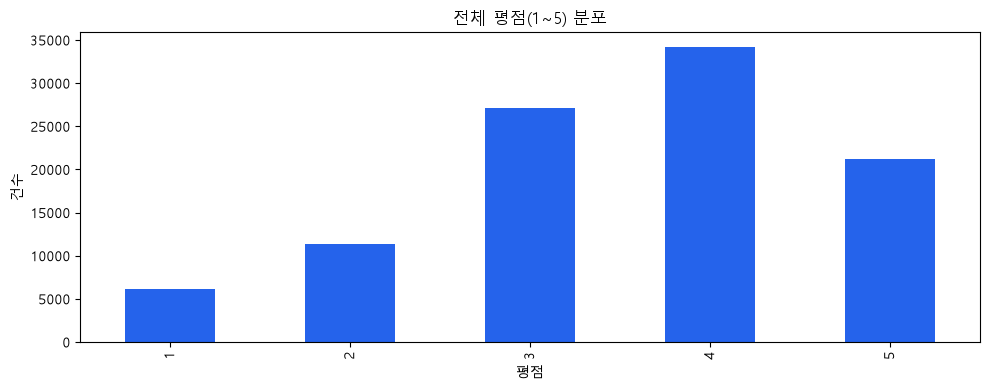

In [25]:
rating_counts_by_star = ratings["rating"].value_counts().sort_index()
print(rating_counts_by_star)
print()
print(f"평균: {ratings['rating'].mean():.3f}")
print(f"중앙값: {ratings['rating'].median():.1f}")
print(f"최빈값: {ratings['rating'].mode()[0]}")
print(f"표준편차: {ratings['rating'].std():.3f}")

fig, ax = plt.subplots()
rating_counts_by_star.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("전체 평점(1~5) 분포")
ax.set_xlabel("평점")
ax.set_ylabel("건수")
plt.tight_layout()
plt.show()

**해석**: 평점은 3~4점에 가장 많이 몰려 있고 1점은 상대적으로 적다. 평균(3.53)이 중앙값(4.0)보다 낮아
약한 음의 왜도(왼쪽 꼬리)를 보인다. 즉 사용자들은 전반적으로 "본 영화를 후하게 평가하는" 경향이 있다
(안 좋아할 영화는애초에 안 보거나 끝까지 안 보고 평가를 남기지 않는 Selection Bias). 이는 추천 모델이
전반적으로 높은 점수를 예측하는 쪽으로 편향될 수 있음을 시사하며, 사용자별 평균으로 중심화(centering)해야
하는 이유이기도 하다.

## 8. EDA — 사용자별 평점 개수 분포 (상세)

이 섹션은 Project06에서 가장 중요하게 다루는 분석이다. 사용자별 평점 개수(`user_rating_count`)는
협업 필터링의 신뢰도, Cold Start 여부, 활동 수준(activity_level) Feature의 근거가 된다.

In [27]:
user_rating_count = ratings.groupby("user_id")["rating"].count().rename("user_rating_count")
print(user_rating_count.describe())
print()
print("사분위수:")
print(user_rating_count.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: user_rating_count, dtype: float64

사분위수:
0.10     23.00
0.25     33.00
0.50     65.00
0.75    148.00
0.90    244.40
0.95    310.60
0.99    442.54
Name: user_rating_count, dtype: float64


0.10     23.00
0.25     33.00
0.50     65.00
0.75    148.00
0.90    244.40
0.95    310.60
0.99    442.54
Name: user_rating_count, dtype: float64


C:\Users\tjoeun\AppData\Local\Temp\ipykernel_15540\2027374482.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(user_rating_count, vert=False)


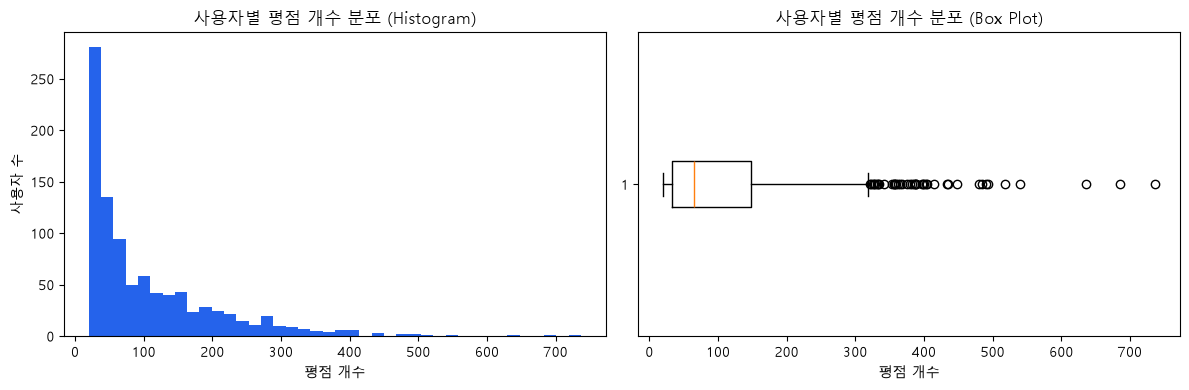

왜도(skewness): 1.903


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_rating_count, bins=40, color="#2563eb")
axes[0].set_title("사용자별 평점 개수 분포 (Histogram)")
axes[0].set_xlabel("평점 개수")
axes[0].set_ylabel("사용자 수")

axes[1].boxplot(user_rating_count, vert=False)
axes[1].set_title("사용자별 평점 개수 분포 (Box Plot)")
axes[1].set_xlabel("평점 개수")

plt.tight_layout()
plt.show()

print("왜도(skewness):", round(skew(user_rating_count), 3))

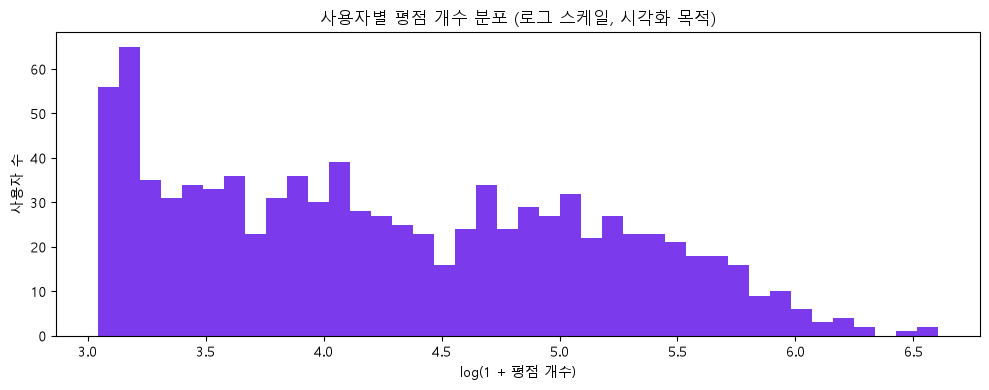

In [29]:
fig, ax = plt.subplots()
ax.hist(np.log1p(user_rating_count), bins=40, color="#7c3aed")
ax.set_title("사용자별 평점 개수 분포 (로그 스케일, 시각화 목적)")
ax.set_xlabel("log(1 + 평점 개수)")
ax.set_ylabel("사용자 수")
plt.tight_layout()
plt.show()

**해석 (Histogram/Box Plot/로그 스케일)**

1. 값이 어디에 집중되어 있는가? → 중앙값 부근(약 60~70건)에 다수가 몰려 있다.
2. 분포가 대칭적인가? → 아니다. 오른쪽으로 긴 꼬리를 가진 비대칭 분포다.
3. 한쪽으로 치우쳐 있는가? → 왼쪽(적은 평점 수)에 다수 사용자가 몰려 있고, 소수의 Power User가
   오른쪽 꼬리를 길게 늘인다. 왜도는 뚜렷한 양의 값을 보인다.
4. 극단값이 존재하는가? → Box Plot 기준 IQR 상단을 크게 벗어나는 사용자들이 존재한다(700건 이상).
5. 실제 오류인가 정상적인 극단값인가? → MovieLens 100K는 "최소 20개 이상 평가한 사용자만" 수집 대상으로
   포함했기 때문에 최솟값 자체가 20 근처이며, 최댓값이 매우 큰 것은 데이터 오류가 아니라 실제로 매우
   적극적으로 평가에 참여한 사용자(Power User)의 정상적인 행동이다.
6. 개인화 추천에 어떤 영향을 미치는가? → 평점이 적은 사용자는 취향 프로필(장르 선호 벡터)의 신뢰도가
   낮고, User-Based CF의 유사도 계산 근거도 부족해 협업 필터링 신호가 약하다. 반대로 평점이 매우 많은
   사용자는 유사도 계산에서 다른 사용자보다 큰 영향력을 가지게 되어 인기 편향을 강화할 수 있다.
7. Feature Engineering이 필요한가? → 그렇다. 활동 수준을 구간화한 `activity_level` Feature와,
   하이브리드 추천에서 활동 수준별로 가중치를 다르게 주는 전략이 필요하다.
8. 어떤 알고리즘에 영향을 미치는가? → User-Based/Item-Based CF, SVD처럼 평점 데이터 자체를 사용하는
   알고리즘일수록 영향이 크다. Content-Based는 평점이 아니라 장르 정보를 쓰므로 상대적으로 영향이 적다.

**로그 스케일에 대한 주의**: 위 로그 변환 그래프는 오직 시각화(긴 꼬리를 좀 더 균등하게 보기 위함) 목적이며,
`activity_level` Feature 자체는 원본 `user_rating_count`의 백분위수를 기준으로 구간화한다(로그값을 저장하지 않는다).

user_rating_count
Low Activity       477
Medium Activity    277
High Activity      141
Power User          48
Name: count, dtype: int64


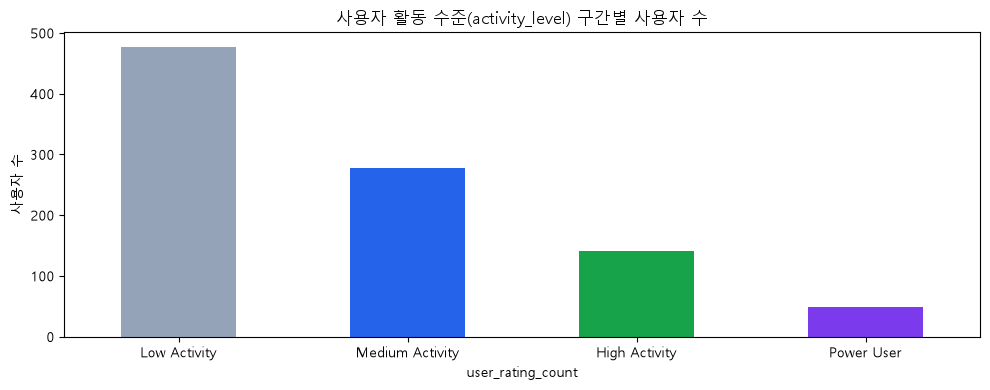

In [30]:
activity_level = fe.bin_by_quantile(
    user_rating_count, fe.ACTIVITY_LEVEL_QUANTILES, fe.ACTIVITY_LEVEL_LABELS
)
activity_counts = activity_level.value_counts().reindex(fe.ACTIVITY_LEVEL_LABELS)
print(activity_counts)

fig, ax = plt.subplots()
activity_counts.plot(kind="bar", ax=ax, color=["#94a3b8", "#2563eb", "#16a34a", "#7c3aed"])
ax.set_title("사용자 활동 수준(activity_level) 구간별 사용자 수")
ax.set_ylabel("사용자 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

활동 수준 구간은 임의로 고정한 값이 아니라 **실제 분포의 백분위수(0~50%, 50~80%, 80~95%, 95~100%)**로
나눈 것이다. 이렇게 나누면 "대부분의 사용자(Low+Medium, 약 80%)는 활동량이 적고, 상위 20%가 High Activity와
Power User"라는 전형적인 Long Tail 구조가 그대로 드러난다.

**왜 평점이 적은 사용자를 무조건 삭제하면 안 되는가?** 실제 서비스에서 신규/저활동 사용자는 절대 사라지지
않는 세그먼트다. 이들을 학습 데이터에서 제외하면 정확도 지표는 좋아 보일 수 있어도, 실제 서비스에서 가장
많이 마주치는 "Cold Start에 가까운 사용자"에 대한 대응 전략을 검증할 수 없게 된다. Project06은 이 사용자들을
삭제하는 대신, `activity_level`을 Feature로 만들어 하이브리드 추천의 가중치를 다르게 적용하는 방식으로 대응한다.

## 9. EDA — 영화별 평점 개수 분포 (Long Tail)

count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
Name: movie_rating_count, dtype: float64
평점이 20건 미만인 영화 수: 743 / 1682


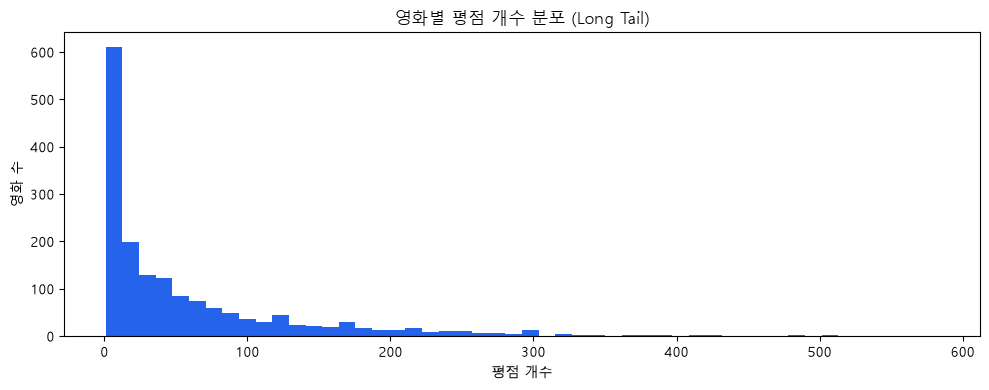

In [31]:
movie_rating_count = ratings.groupby("movie_id")["rating"].count().rename("movie_rating_count")
# 평점이 하나도 없는 영화도 포함해서 분포를 본다.
movie_rating_count_full = movie_rating_count.reindex(movies_raw["movie_id"], fill_value=0)

print(movie_rating_count_full.describe())
print("평점이 20건 미만인 영화 수:", (movie_rating_count_full < 20).sum(), "/", len(movie_rating_count_full))

fig, ax = plt.subplots()
ax.hist(movie_rating_count_full, bins=50, color="#2563eb")
ax.set_title("영화별 평점 개수 분포 (Long Tail)")
ax.set_xlabel("평점 개수")
ax.set_ylabel("영화 수")
plt.tight_layout()
plt.show()

영화 쪽은 사용자보다 더 극단적인 Long Tail을 보인다. 소수의 "블록버스터"급 영화가 압도적으로 많은 평점을
받는 반면, 다수의 영화는 평점이 거의 없다(신규 영화 문제). 이 때문에 Item-Based CF 유사도 계산에는
`MIN_RATING_COUNT_FOR_MOVIE_CF` 이상 평가된 영화만 포함시키고, 평점이 부족한 영화는 인기도 계산 시
Bayesian Weighted Rating으로 "평균 평점만으로 과대평가되지 않도록" 보정한다.

## 10. EDA — 사용자별/영화별 평균 평점 분포

/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/2731860538.py:12: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/2731860538.py:12: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/2731860538.py:12: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/2731860538.py:12: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/2731860538.py:12: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/i

/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/pytho

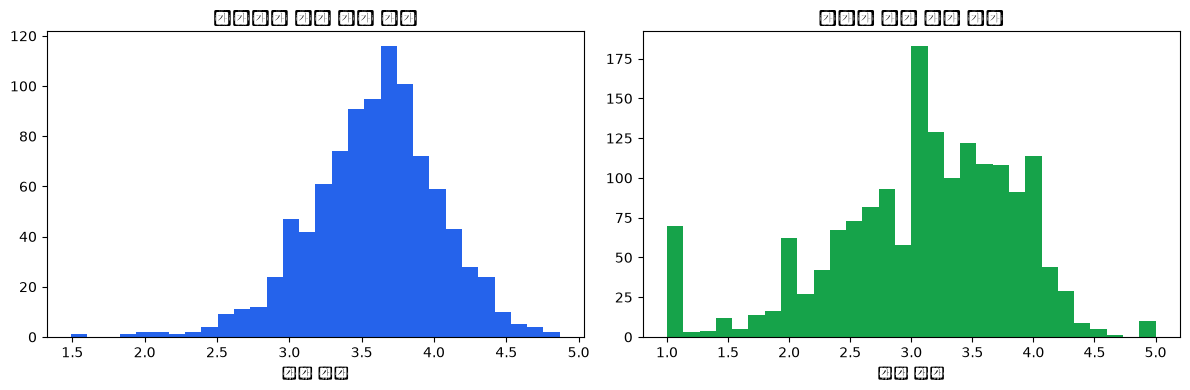

사용자별 평균 평점 표준편차 범위: 0.445


In [20]:
user_rating_mean = ratings.groupby("user_id")["rating"].mean().rename("user_rating_mean")
movie_rating_mean = ratings.groupby("movie_id")["rating"].mean().rename("movie_rating_mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_rating_mean, bins=30, color="#2563eb")
axes[0].set_title("사용자별 평균 평점 분포")
axes[0].set_xlabel("평균 평점")

axes[1].hist(movie_rating_mean, bins=30, color="#16a34a")
axes[1].set_title("영화별 평균 평점 분포")
axes[1].set_xlabel("평균 평점")
plt.tight_layout()
plt.show()

print("사용자별 평균 평점 표준편차 범위:", round(user_rating_mean.std(), 3))

사용자별 평균 평점은 대체로 3~4점 사이에 몰려 있지만, 후하게 평가하는 사용자와 엄격하게 평가하는 사용자
사이의 편차가 분명히 존재한다. 이 차이를 그대로 두고 협업 필터링을 하면 "평점이 후한 사용자"와 유사도가
높게 잡히는 왜곡이 생기므로, `mean_center_user_item_matrix()`에서 사용자 평균을 빼는 중심화가 필요하다.

영화별 평균 평점은 평점 수가 적은 영화일수록 극단값(1.0 또는 5.0)에 몰리는 경향이 있다(단 한두 명이 준
평점이 그대로 평균이 되므로). 이는 "평균 평점만 보고 인기 영화를 판단하면 안 되는 이유"이며,
`weighted_rating`(Bayesian Weighted Rating)을 사용하는 근거다.

## 11. EDA — 사용자별/영화별 평점 표준편차

/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/3166284407.py:9: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/3166284407.py:9: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/3166284407.py:9: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/3166284407.py:9: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/3166284407.py:9: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykern

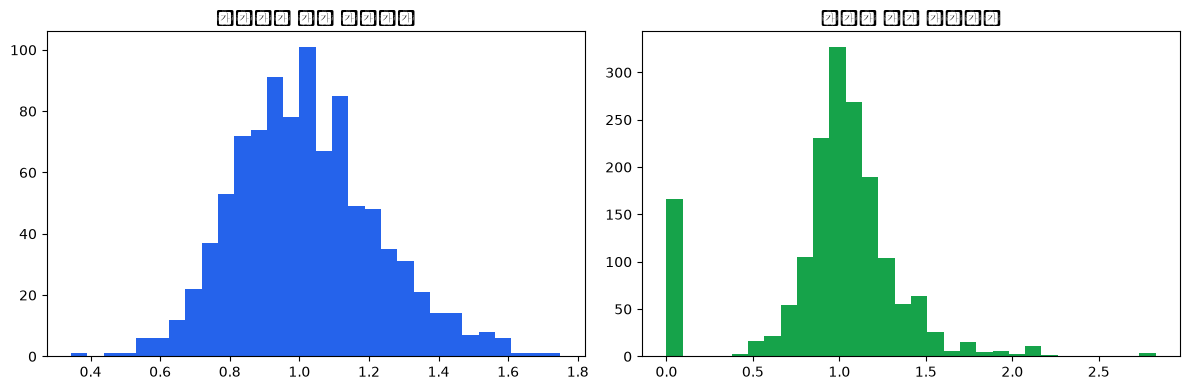

In [21]:
user_rating_std = ratings.groupby("user_id")["rating"].std().fillna(0.0).rename("user_rating_std")
movie_rating_std = ratings.groupby("movie_id")["rating"].std().fillna(0.0).rename("movie_rating_std")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_rating_std, bins=30, color="#2563eb")
axes[0].set_title("사용자별 평점 표준편차")
axes[1].hist(movie_rating_std, bins=30, color="#16a34a")
axes[1].set_title("영화별 평점 표준편차")
plt.tight_layout()
plt.show()

표준편차가 0에 가까운 사용자는 거의 항상 비슷한 점수만 주는 사용자다(예: 매번 4점). 이런 사용자는
코사인 유사도 계산에서 다른 사용자와의 "차이"가 잘 드러나지 않아 협업 필터링의 변별력이 낮아질 수 있다.
영화 쪽 표준편차가 큰 영화는 "호불호가 갈리는 영화"이고, 표준편차가 작으면서 평균이 높은 영화는
"대중적으로 안정적으로 사랑받는 영화"로 해석할 수 있다(인기 추천에 적합).

## 12. EDA — 사용자 인구통계 분포

나이/성별/직업 분포를 확인한다. 특정 인구통계 집단에 대한 과도한 일반화나 차별적 추천으로 이어지지 않도록,
이 정보는 참고용으로만 살펴보고 추천 알고리즘의 직접적인 입력으로는 사용하지 않는다
(추천은 어디까지나 각 개인의 평점 이력·장르 선호를 기반으로 한다).

/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/1652731260.py:16: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/1652731260.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/1652731260.py:16: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/1652731260.py:16: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/1652731260.py:16: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_

/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/private/tmp/claude-501/-Users-leekm-AI-Service-Lab-T/f974fcb1-479a-474b-b0e5-5b8da4bf60a7/scratchpad/venv/lib/pytho

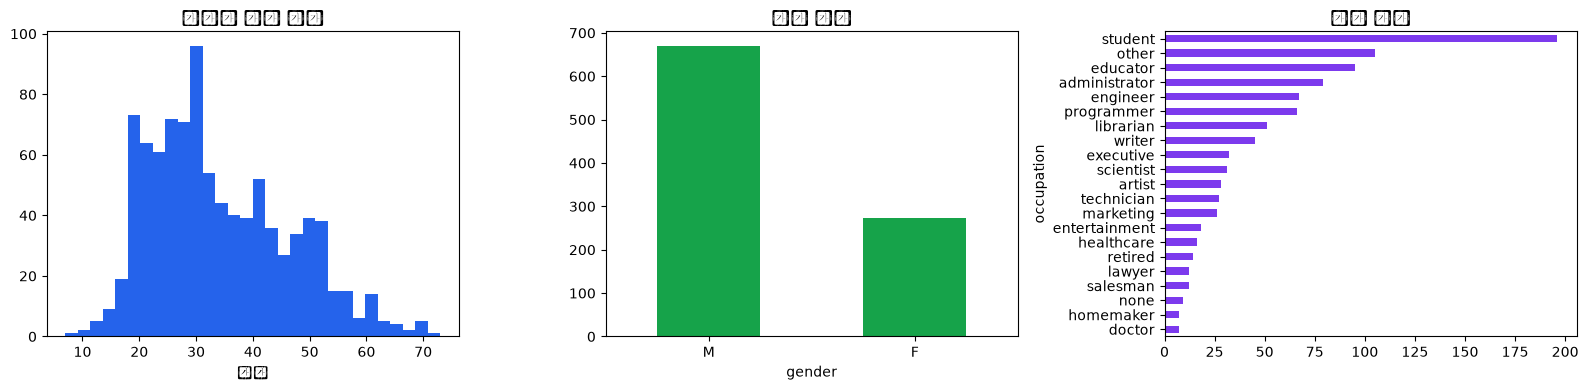

연령 중앙값: 31.0
gender
M    0.71
F    0.29
Name: proportion, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(users_raw["age"], bins=30, color="#2563eb")
axes[0].set_title("사용자 연령 분포")
axes[0].set_xlabel("나이")

users_raw["gender"].value_counts().plot(kind="bar", ax=axes[1], color="#16a34a")
axes[1].set_title("성별 분포")
plt.setp(axes[1].get_xticklabels(), rotation=0)

occupation_counts = users_raw["occupation"].value_counts()
occupation_counts.plot(kind="barh", ax=axes[2], color="#7c3aed")
axes[2].set_title("직업 분포")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("연령 중앙값:", users_raw["age"].median())
print(users_raw["gender"].value_counts(normalize=True).round(3))

연령대는 20~30대에 집중되어 있고, 성별은 남성이 더 많다(약 71%). 직업은 `student`, `other`, `educator`
비중이 높다. 1990년대 후반 인터넷/영화 평가 서비스 이용자 특성이 반영된 결과로 보이며, 이 분포 자체가
실제 전체 영화 관람객을 대표한다고 볼 수는 없다. 앞서 언급했듯 이 정보는 프로필 표시용으로만 사용하고,
추천 점수 계산에는 관여시키지 않는다.

## 13. EDA — 장르 분포

In [23]:
genre_movie_counts = movies_raw[fe.GENRE_COLUMNS].sum().sort_values(ascending=False)
genre_ratings = movies_raw[["movie_id"] + fe.GENRE_COLUMNS].merge(
    ratings[["movie_id", "rating"]], on="movie_id", how="left"
)
genre_rating_count = {g: int(genre_ratings.loc[genre_ratings[g] == 1, "rating"].count()) for g in fe.GENRE_COLUMNS}
genre_rating_mean = {g: float(genre_ratings.loc[genre_ratings[g] == 1, "rating"].mean()) for g in fe.GENRE_COLUMNS}

genre_summary = pd.DataFrame({
    "movie_count": genre_movie_counts,
    "rating_count": pd.Series(genre_rating_count),
    "rating_mean": pd.Series(genre_rating_mean),
}).sort_values("movie_count", ascending=False)
genre_summary.round(3)

,movie_count,rating_count,rating_mean
Drama,725,39895,3.687
Comedy,505,29832,3.394
Action,251,25589,3.480
Thriller,251,21872,3.509
Romance,247,19461,3.622
Adventure,135,13753,3.504
Children's,122,7182,3.353
Crime,109,8055,3.632
Sci-Fi,101,12730,3.561
Horror,92,5317,3.290


/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4123149562.py:5: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4123149562.py:5: UserWarning: Glyph 47476 (\N{HANGUL SYLLABLE REU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4123149562.py:5: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4123149562.py:5: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4123149562.py:5: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipyker

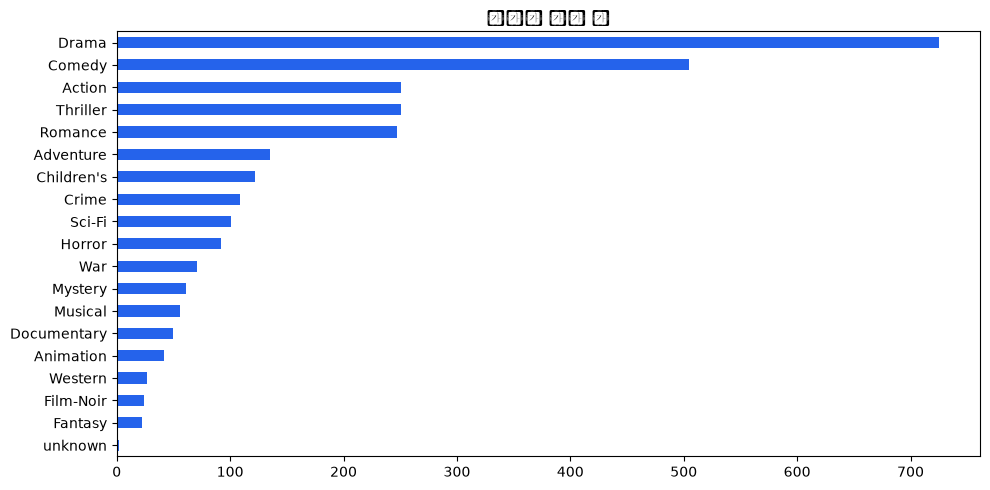

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
genre_summary["movie_count"].plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("장르별 영화 수")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

`Drama`, `Comedy`가 압도적으로 많고, `Fantasy`, `Film-Noir`, `unknown` 등은 매우 적다. 장르별 평균 평점은
`Film-Noir`, `War`, `Documentary`처럼 영화 수는 적지만 평균 평점이 높은 장르가 존재하는 반면, 절대적인
평점 수는 `Drama`, `Comedy`에 집중된다. 이 분포는 사용자 장르 선호 벡터(`genre_pref_*`)를 계산할 때
장르별 기본 노출 빈도가 다르다는 점을 알려준다 — 영화 수가 많은 장르일수록 사용자가 우연히 더 많이 평가할
가능성이 크므로, 단순히 "본 횟수"가 아니라 "평점(선호도)"을 반영해 선호 벡터를 만드는 이유가 된다.

## 14. EDA — 개봉연도 분포

/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/256412322.py:9: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/256412322.py:9: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/256412322.py:9: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/256412322.py:9: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/256412322.py:9: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_453

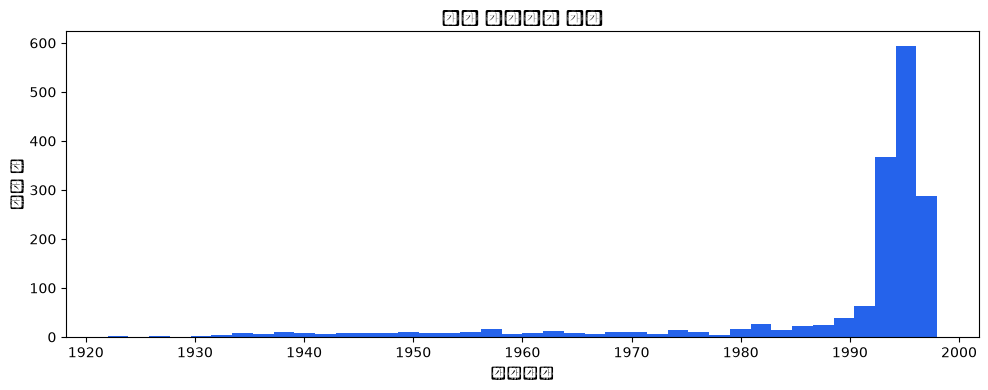

개봉연도 결측(제목에서 연도를 추출하지 못한 영화): 1
count    1681.000000
mean     1989.071386
std        14.301836
min      1922.000000
25%      1992.000000
50%      1995.000000
75%      1996.000000
max      1998.000000
Name: title, dtype: float64


In [25]:
release_years = movies_raw["title"].apply(lambda t: fe.split_title_and_year(t)[1])
release_years = release_years.dropna().astype(int)

fig, ax = plt.subplots()
ax.hist(release_years, bins=40, color="#2563eb")
ax.set_title("영화 개봉연도 분포")
ax.set_xlabel("개봉연도")
ax.set_ylabel("영화 수")
plt.tight_layout()
plt.show()

print("개봉연도 결측(제목에서 연도를 추출하지 못한 영화):", movies_raw.shape[0] - release_years.shape[0])
print(release_years.describe())

1990년대 중후반 영화가 압도적으로 많다(데이터 수집 시점이 1997~1998년이기 때문). 1920~1950년대 고전 영화도
소수 존재한다. 이 분포 때문에 "선호 개봉연도" Feature는 절대적인 연도보다, 사용자가 상대적으로 최신 영화를
좋아하는지 고전 영화를 좋아하는지를 구분하는 용도로 더 유용하다.

## 15. EDA — 시간(timestamp) 분포

/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/993417394.py:10: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/993417394.py:10: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/993417394.py:10: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/993417394.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/993417394.py:10: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykerne

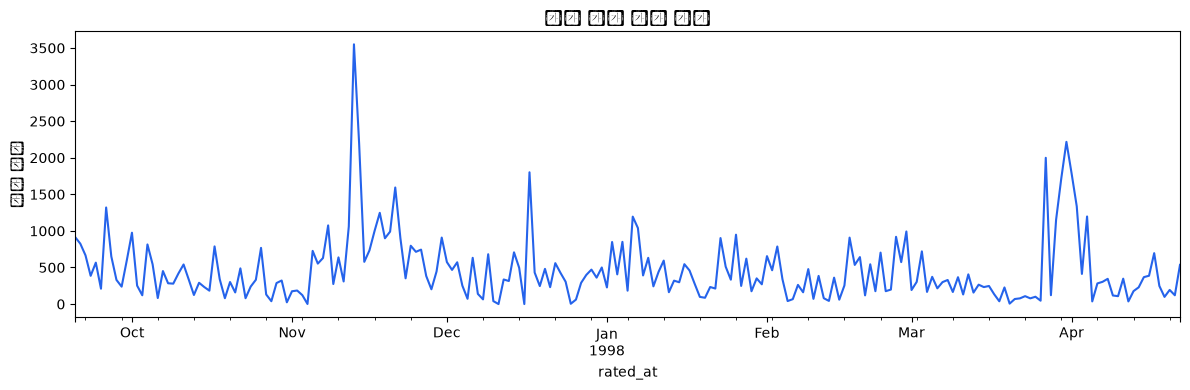

데이터 내 최초 평가일: 1997-09-20 03:05:10
데이터 내 최근 평가일: 1998-04-22 23:10:38


In [26]:
ratings_with_time = ratings.copy()
ratings_with_time["rated_at"] = pd.to_datetime(ratings_with_time["timestamp"], unit="s")

daily_counts = ratings_with_time.set_index("rated_at").resample("D").size()

fig, ax = plt.subplots(figsize=(12, 4))
daily_counts.plot(ax=ax, color="#2563eb")
ax.set_title("일별 평점 활동 건수")
ax.set_ylabel("평점 건수")
plt.tight_layout()
plt.show()

print("데이터 내 최초 평가일:", ratings_with_time["rated_at"].min())
print("데이터 내 최근 평가일:", ratings_with_time["rated_at"].max())

평점 활동은 특정 기간에 몰려서 발생하는 구간이 있다(신규 사용자 유입 이벤트로 추정). 이 데이터는 이미
과거에 수집이 종료된 데이터이므로, `datetime.now()`처럼 "현재 시점" 기준 Feature를 만들면 안 되고
**데이터 내부의 마지막 timestamp를 기준 시점으로 사용**해야 한다(`build_user_features`의 `active_days` 계산이
이 원칙을 따른다). 또한 평가 시점 순서를 활용한 평가(24장 시간 순서 기반 Holdout)에서, 미래 시점의 정보가
학습에 섞여 들어가는 시간 누수(Data Leakage)에 주의해야 한다.

## 16. 이상치 분석

추천 데이터의 이상치는 일반적인 회귀 데이터처럼 무조건 삭제하지 않는다. 각 사례가 "데이터 오류"인지
"정상적인 행동 패턴"인지 구분해서 판단한다.

In [27]:
# 1) 평점을 지나치게 많이/적게 남긴 사용자
top_active_users = user_rating_count.sort_values(ascending=False).head(5)
print("평점을 가장 많이 남긴 사용자 Top 5:\n", top_active_users)
print()
print("평점을 가장 적게 남긴 사용자 수(최소 20건 = 데이터셋 최저 기준):", (user_rating_count == 20).sum())

# 2) 평가 수가 매우 많은/적은 영화
print()
print("평가 수가 가장 많은 영화 Top 5:")
print(movie_rating_count.sort_values(ascending=False).head(5))

# 3) 평균 평점은 높지만 평가 수가 매우 적은 영화 (신뢰하기 어려운 고평점)
suspicious = movie_rating_count[movie_rating_count <= 3].index
suspicious_high_mean = movie_rating_mean.loc[movie_rating_mean.index.isin(suspicious)]
suspicious_high_mean = suspicious_high_mean[suspicious_high_mean >= 4.5]
print()
print(f"평점 3건 이하인데 평균이 4.5점 이상인 영화: {len(suspicious_high_mean)}편 "
      f"(평가 수가 적어 평균이 쉽게 극단으로 치우친 사례)")

# 4) 항상 같은 점수만 주는 사용자
always_same_score_users = user_rating_std[user_rating_std == 0]
print()
print(f"평점 표준편차가 0인(항상 같은 점수만 주는) 사용자: {len(always_same_score_users)}명")

평점을 가장 많이 남긴 사용자 Top 5:
 user_id
405    737
655    685
13     636
450    540
276    518
Name: user_rating_count, dtype: int64

평점을 가장 적게 남긴 사용자 수(최소 20건 = 데이터셋 최저 기준): 32

평가 수가 가장 많은 영화 Top 5:
movie_id
50     583
258    509
100    508
181    507
294    485
Name: movie_rating_count, dtype: int64

평점 3건 이하인데 평균이 4.5점 이상인 영화: 13편 (평가 수가 적어 평균이 쉽게 극단으로 치우친 사례)

평점 표준편차가 0인(항상 같은 점수만 주는) 사용자: 0명


**판단**:

- 평점을 매우 많이 남긴 사용자(Power User)는 데이터 오류가 아니라 정상적인 적극적 참여자다. 삭제하면
  협업 필터링에 필요한 신호가 오히려 줄어들기 때문에 삭제하지 않는다. 다만 유사도 계산에서 이들의 영향력이
  과도하게 커지지 않도록(사용자 평균 중심화) 이미 처리하고 있다.
- 평가 수가 3건 이하인데 평균이 4.5점 이상인 영화는 "실제로 훌륭한 영화"일 수도 있지만 "평가 수가 적어
  우연히 높게 나온 평균"일 가능성이 크다 → 삭제하지는 않지만 `weighted_rating`으로 보정해 인기 추천/랭킹에서
  과대평가되지 않도록 한다.
- 표준편차가 0인 사용자는 정보량이 적어 협업 필터링 유사도 계산에서 크게 도움이 되지 않지만, 데이터 오류는
  아니므로 삭제하지 않고 그대로 둔다(평점 개수 필터로 자연스럽게 영향력이 제한된다).
- 결론적으로 이 데이터셋에서는 명확한 "삭제해야 할 오류"가 발견되지 않았으며, 모든 극단값은 Feature
  Engineering(가중 평점, 활동 수준 구간화, 평점 중심화)으로 대응한다.

## 17. 왜도 분석

In [28]:
skew_targets = {
    "user_rating_count": user_rating_count,
    "movie_rating_count": movie_rating_count_full,
    "user_rating_mean": user_rating_mean,
    "movie_rating_mean": movie_rating_mean,
}
for name, series in skew_targets.items():
    print(f"{name:20s} skew = {skew(series):.3f}")

user_rating_count    skew = 1.903
movie_rating_count   skew = 2.311
user_rating_mean     skew = -0.444
movie_rating_mean    skew = -0.699


`user_rating_count`와 `movie_rating_count`는 뚜렷한 양의 왜도(긴 오른쪽 꼬리)를 보인다. 이는 추천 데이터에서
매우 흔한 현상으로, 소수의 인기 아이템/적극적 사용자가 전체 상호작용의 큰 비중을 차지하는 구조(파레토 법칙과
유사) 때문이다. `user_rating_mean`, `movie_rating_mean`은 상대적으로 왜도가 작다(평점 척도가 1~5로 제한되어
있어 극단으로 치우치기 어렵다).

앞서 로그 스케일 시각화에서 언급했듯, 왜도가 있다는 이유만으로 원본 Feature를 로그/Box-Cox 변환해서 모델
입력으로 사용하지는 않는다. `activity_level`, `popularity_level`처럼 **분포 기반 구간화(binning)**로 다루는
쪽이 해석 가능성과 서비스 요구사항(활동 수준별 전략 분기) 측면에서 더 적합하다.

## 18. 영화 Feature Engineering

`feature_engineering.build_movie_features()`를 실행해 영화별 파생 Feature를 만든다. 적용 전/후를 비교한다.

In [29]:
print("적용 전 movies_raw 컬럼:", list(movies_raw.columns))

movie_features, popularity_m, popularity_C = fe.build_movie_features(movies_raw, ratings)
movie_features["popularity_score"] = fe.normalize_scores(movie_features["weighted_rating"])

print("적용 후 movie_features 컬럼:", list(movie_features.columns))
print("적용 전/후 크기:", movies_raw.shape, "->", movie_features.shape)
print(f"인기도(Bayesian Weighted Rating) 최소 투표 수 m = {popularity_m:.2f}건, 전체 평균 C = {popularity_C:.4f}")
movie_features.head(3)

적용 전 movies_raw 컬럼: ['movie_id', 'title', 'release_date', 'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
적용 후 movie_features 컬럼: ['title', 'clean_title', 'release_year', 'search_title', 'genres', 'rating_count', 'rating_mean', 'rating_std', 'weighted_rating', 'popularity_level', 'popularity_score']
적용 전/후 크기: (1682, 23) -> (1682, 11)
인기도(Bayesian Weighted Rating) 최소 투표 수 m = 43.00건, 전체 평균 C = 3.0760


,title,clean_title,release_year,search_title,genres,rating_count,rating_mean,rating_std,weighted_rating,popularity_level,popularity_score
movie_id,,,,,,,,,,,
1,Toy Story (1995),Toy Story,1995.0,toy story,"[Animation, Children's, Comedy]",452,3.878319,0.927897,3.808626,Blockbuster,0.737741
2,GoldenEye (1995),GoldenEye,1995.0,goldeneye,"[Action, Adventure, Thriller]",131,3.206107,0.966497,3.173965,Popular,0.392767
3,Four Rooms (1995),Four Rooms,1995.0,four rooms,[Thriller],90,3.033333,1.212760,3.047142,Moderate,0.323831


In [30]:
print(movie_features["popularity_level"].value_counts())

# weighted_rating이 실제로 "평점 수가 적은 영화의 과대평가"를 완화하는지 확인
example = movie_features[(movie_features["rating_count"] <= 3) & (movie_features["rating_mean"] >= 4.5)]
print()
print("평점 3건 이하 + 평균 4.5 이상인 영화의 weighted_rating 비교 (원래 평균 대비 인기도 기준으로 보정됨):")
example[["title", "rating_count", "rating_mean", "weighted_rating"]].head(5)

popularity_level
Niche          855
Moderate       493
Popular        249
Blockbuster     85
Name: count, dtype: int64

평점 3건 이하 + 평균 4.5 이상인 영화의 weighted_rating 비교 (원래 평균 대비 인기도 기준으로 보정됨):


,title,rating_count,rating_mean,weighted_rating
movie_id,,,,
814,"Great Day in Harlem, A (1994)",1,5.0,3.119771
1122,They Made Me a Criminal (1939),1,5.0,3.119771
1189,Prefontaine (1997),3,5.0,3.201520
1201,Marlene Dietrich: Shadow and Light (1996),1,5.0,3.119771
1293,Star Kid (1997),3,5.0,3.201520


`weighted_rating`은 평점 수가 적은 영화의 평균 평점을 전체 평균(C) 쪽으로 끌어당겨, "평점 3건이 전부 5점이라
평균이 5.0인 영화"가 "평점 300건에 평균 4.3인 영화"보다 인기 랭킹에서 앞서는 문제를 완화한다. `popularity_level`
은 이 값을 다시 사용자 활동 수준과 동일한 4구간 백분위수 기준으로 나눈 것이다.

**데이터 누수 가능성**: `rating_count`, `rating_mean`, `weighted_rating`은 전체 `ratings` 데이터로 계산되므로,
만약 이후 평가(24장)에서 Train/Test를 나눈다면 이 통계량도 Train 기준으로 다시 계산해야 정확한 오프라인
평가가 된다. Notebook의 24장 평가에서는 이 점을 반영해 Train 데이터만으로 통계를 다시 낸다.

## 19. 사용자 Feature Engineering (취향 프로필)

`feature_engineering.build_user_features()`를 실행해 사용자별 취향 프로필을 만든다.

In [31]:
genre_matrix = fe.build_genre_matrix(movies_raw)
user_features = fe.build_user_features(ratings, users_raw, movies_raw, genre_matrix)

print("생성된 컬럼 수:", len(user_features.columns))
print(user_features.shape)
user_features[[
    "age", "gender", "occupation", "rating_count", "rating_mean", "rating_std",
    "activity_level", "favorite_genres", "preferred_release_year", "active_days",
]].head(5)

생성된 컬럼 수: 34
(943, 34)


,age,gender,occupation,rating_count,rating_mean,rating_std,activity_level,favorite_genres,preferred_release_year,active_days
user_id,,,,,,,,,,
1,24,M,technician,272,3.610294,1.263585,High Activity,"[Drama, Sci-Fi, Comedy]",1993.0,171
2,53,F,other,62,3.709677,1.030472,Low Activity,"[Drama, Romance, Comedy]",1996.0,4
3,23,M,writer,54,2.796296,1.219026,Low Activity,"[Documentary, Adventure, Romance]",1997.0,0
4,24,M,technician,24,4.333333,0.916831,Low Activity,"[Thriller, Drama, Comedy]",1997.0,0
5,33,F,other,175,2.874286,1.362963,High Activity,"[Sci-Fi, Animation, Crime]",1991.0,41


In [32]:
# 장르 선호 벡터가 "본 횟수"가 아니라 "평점"을 반영하는지 확인하는 예시
example_user = user_features.index[0]
print(f"User #{example_user} 선호 장르: {user_features.loc[example_user, 'favorite_genres']}")

genre_pref_cols = [f"genre_pref_{g}" for g in fe.GENRE_COLUMNS]
user_features.loc[example_user, genre_pref_cols].sort_values(ascending=False).head(5)

User #1 선호 장르: ['Drama', 'Sci-Fi', 'Comedy']


genre_pref_Drama       0.290323
genre_pref_Comedy      0.126100
genre_pref_Sci-Fi      0.126100
genre_pref_Romance     0.120235
genre_pref_Thriller    0.093842
Name: 1, dtype: float64

장르 선호 벡터(`genre_pref_*`)는 `(rating - 3)`을 가중치로 사용해 계산했다. 즉 3점(중립)은 선호도에 기여하지
않고, 4~5점을 준 장르는 양의 가중치, 1~2점을 준 장르는 음의 가중치를 갖는다. 이렇게 하면 "많이 본 장르"가
아니라 "좋아하는 장르"를 더 정확히 포착할 수 있다(예: 어떤 사용자가 Horror 영화를 10편 봤지만 전부 낮게
평가했다면, 단순 시청 횟수 기반 방식은 Horror를 선호 장르로 잘못 판단하지만 이 방식은 그렇지 않다).

`preferred_release_year`는 **HIGH_RATING_THRESHOLD(4점) 이상**을 준 영화의 개봉연도 중앙값으로 계산했다.
모든 평가가 아니라 "높게 평가한 영화"만 사용하는 이유는, 선호 시대를 파악하는 것이 목적이지 단순히 어떤
시대 영화를 많이 봤는지를 파악하는 것이 목적이 아니기 때문이다.

## 20. Interaction Feature Engineering — 사용자-영화 행렬 / 유사도

사용자-영화 평점 행렬을 만들고, 사용자 평균으로 중심화한 뒤 Item 유사도와 User 유사도를 계산한다.

In [33]:
user_item_matrix = fe.build_user_item_matrix(ratings)
print("사용자-영화 행렬 크기:", user_item_matrix.shape)

sparsity = 1 - ratings.shape[0] / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
print(f"희소도(Sparsity): {sparsity:.4%} (대부분의 칸이 비어 있음을 의미)")

centered_matrix, user_mean = fe.mean_center_user_item_matrix(user_item_matrix)
centered_matrix.iloc[:3, :5]

사용자-영화 행렬 크기: (943, 1682)
희소도(Sparsity): 93.6953% (대부분의 칸이 비어 있음을 의미)


movie_id,1,2,3,4,5
user_id,,,,,
1,1.389706,-0.610294,0.389706,-0.610294,-0.610294
2,0.290323,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000


In [34]:
min_movie_count_for_cf = fe.determine_movie_cf_min_count(movie_features["rating_count"])
eligible_movie_ids = movie_features[movie_features["rating_count"] >= min_movie_count_for_cf].index
print(f"Item-CF 대상 영화(평점 {min_movie_count_for_cf}건 이상): {len(eligible_movie_ids)} / {movie_features.shape[0]}")

item_similarity = fe.build_item_similarity_matrix(centered_matrix, eligible_movie_ids)
print("Item 유사도 행렬 크기:", item_similarity.shape)

eligible_user_ids = user_features[user_features["rating_count"] >= fe.MIN_RATING_COUNT_FOR_USER_CF].index
user_similarity = fe.build_user_similarity_matrix(centered_matrix, eligible_user_ids)
print("User 유사도 행렬 크기:", user_similarity.shape)

Item-CF 대상 영화(평점 16건 이상): 1010 / 1682
Item 유사도 행렬 크기: (1010, 1010)


User 유사도 행렬 크기: (943, 943)


행렬의 희소도(Sparsity)가 매우 높다(대부분의 사용자가 전체 영화 중 극히 일부만 평가). 이것이 협업 필터링의
근본적인 어려움이다 — 두 사용자/영화 사이의 공통 평가가 거의 없으면 유사도 계산 자체가 불안정해진다.
그래서 Item 유사도는 평점 수가 일정 기준(`min_movie_count_for_cf`, 실제 값은 `rating_count`의 40번째
백분위수로 데이터 기반 결정) 이상인 영화만 대상으로 계산한다.

## 21. Matrix Factorization (SVD)

`TruncatedSVD`로 사용자-영화 중심화 평점 행렬을 잠재 요인으로 분해하고, 예측 평점 행렬을 재구성한다.

In [35]:
svd_result = fe.fit_svd_model(centered_matrix, user_mean, n_components=fe.SVD_N_COMPONENTS)
print(f"잠재 요인 수: {svd_result['n_components']}")
print(f"설명된 분산 비율: {svd_result['explained_variance_ratio']:.4f}")
svd_result["predicted_ratings"].iloc[:3, :5].round(2)

잠재 요인 수: 20
설명된 분산 비율: 0.2218


movie_id,1,2,3,4,5
user_id,,,,,
1,4.63,3.58,3.72,3.40,3.24
2,3.56,3.76,3.60,3.71,3.71
3,2.66,2.78,2.70,2.88,2.81


잠재 요인(latent factor) 20개로 원래 943x1682 행렬의 분산 중 약 22%를 설명한다. 영화 추천에서 SVD는
"사용자가 명시적으로 평가하지 않은 영화에 대해서도 평점을 예측"할 수 있다는 점이 Item/User-CF와 다른 큰
장점이다(밀집 행렬로 재구성되므로 Cold Start 영화가 아니라면 항상 예측값이 존재한다). 다만 잠재 요인이
무엇을 의미하는지 사람이 직접 해석하기 어렵다는 한계가 있다(설명 가능성이 Content-Based보다 낮다).

## 22. 추천 알고리즘 구현

앞서 만든 Feature/유사도 행렬/SVD 결과를 이용해 6가지 추천 방식을 구현하고, 동일한 예시 사용자에게
각 알고리즘이 어떤 영화를 추천하는지 비교한다. 이 함수들은 `recommendation_service.py`의 서빙 로직과
동일한 수식을 사용하되, Notebook에서는 비교·평가를 위해 계산 과정을 그대로 노출한다.

In [36]:
def unseen_movies(user_id, ratings_df, all_movie_ids):
    seen = set(ratings_df.loc[ratings_df["user_id"] == user_id, "movie_id"])
    return np.array([m for m in all_movie_ids if m not in seen])


def popularity_recommend(exclude_ids, movie_feat, top_n=10):
    df = movie_feat.sort_values("weighted_rating", ascending=False)
    df = df[~df.index.isin(set(exclude_ids))].head(top_n)
    return df.index.tolist(), df["weighted_rating"]


def content_scores(user_id, candidate_ids, user_feat, genre_mat):
    vector = fe.get_genre_preference_vector(user_feat.loc[user_id]).reshape(1, -1)
    candidate_genre = genre_mat.loc[candidate_ids]
    scores = cosine_similarity(vector, candidate_genre)[0]
    return pd.Series(scores, index=candidate_ids)


def item_cf_scores(user_id, candidate_ids, ratings_df, item_sim, user_mean_s):
    user_mean = float(user_mean_s.get(user_id, 3.0))
    user_ratings = ratings_df.loc[ratings_df["user_id"] == user_id, ["movie_id", "rating"]].set_index("movie_id")["rating"]
    rated_in_sim = user_ratings.index.intersection(item_sim.columns)
    cand_in_sim = pd.Index(candidate_ids).intersection(item_sim.index)
    result = pd.Series(np.nan, index=candidate_ids)
    if len(rated_in_sim) == 0 or len(cand_in_sim) == 0:
        return result
    devs = (user_ratings.loc[rated_in_sim] - user_mean).to_numpy()
    sub = item_sim.loc[cand_in_sim, rated_in_sim].to_numpy()
    numer = sub @ devs
    denom = np.abs(sub).sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        pred = user_mean + numer / denom
    pred = np.where(denom > 1e-9, pred, np.nan)
    result.loc[cand_in_sim] = np.clip(pred, 1.0, 5.0)
    return result


def user_cf_scores(user_id, candidate_ids, ratings_df, user_sim, user_mean_s, k=30):
    result = pd.Series(np.nan, index=candidate_ids)
    if user_id not in user_sim.index:
        return result
    sims = user_sim.loc[user_id].drop(labels=[user_id], errors="ignore")
    sims = sims[sims > 0].sort_values(ascending=False).head(k)
    if sims.empty:
        return result
    neighbor_ratings = ratings_df[ratings_df["user_id"].isin(sims.index) & ratings_df["movie_id"].isin(candidate_ids)]
    if neighbor_ratings.empty:
        return result
    pivot = neighbor_ratings.pivot_table(index="user_id", columns="movie_id", values="rating")
    neighbor_means = user_mean_s.reindex(pivot.index)
    dev = pivot.sub(neighbor_means, axis=0)
    sims_aligned = sims.reindex(pivot.index)
    numer = dev.mul(sims_aligned, axis=0).sum(axis=0, skipna=True)
    mask = dev.notna()
    denom = mask.mul(sims_aligned.abs(), axis=0).sum(axis=0)
    user_mean = float(user_mean_s.get(user_id, 3.0))
    with np.errstate(invalid="ignore", divide="ignore"):
        pred = user_mean + numer / denom.replace(0, np.nan)
    result.loc[pred.index] = pred.clip(1.0, 5.0).to_numpy()
    return result


def svd_scores(user_id, candidate_ids, predicted_ratings):
    if user_id not in predicted_ratings.index:
        return pd.Series(np.nan, index=candidate_ids)
    cols = pd.Index(candidate_ids).intersection(predicted_ratings.columns)
    return predicted_ratings.loc[user_id, cols].reindex(candidate_ids)


def hybrid_recommend(user_id, top_n, ratings_df, movie_feat, genre_mat, user_feat,
                      item_sim, user_sim, predicted_ratings, user_mean_s,
                      weights_by_activity=None, item_cf_w=None, user_cf_w=None):
    # weights_by_activity/item_cf_w/user_cf_w를 지정하지 않으면 feature_engineering.py의
    # 최종(튜닝된) 값을 사용한다. 24장에서 튜닝 전 가중치를 명시적으로 넣어 비교할 때 사용한다.
    weights_by_activity = weights_by_activity or fe.HYBRID_WEIGHTS_BY_ACTIVITY
    item_cf_w = fe.ITEM_CF_WEIGHT_IN_COLLABORATIVE if item_cf_w is None else item_cf_w
    user_cf_w = fe.USER_CF_WEIGHT_IN_COLLABORATIVE if user_cf_w is None else user_cf_w

    activity = user_feat.loc[user_id, "activity_level"]
    weights = weights_by_activity[activity]

    candidates = unseen_movies(user_id, ratings_df, movie_feat.index)
    if len(candidates) == 0:
        candidates = movie_feat.index.to_numpy()

    content = content_scores(user_id, candidates, user_feat, genre_mat)
    item_cf = item_cf_scores(user_id, candidates, ratings_df, item_sim, user_mean_s)
    user_cf = user_cf_scores(user_id, candidates, ratings_df, user_sim, user_mean_s)
    collaborative = fe.normalize_scores(fe.combine_weighted_scores(
        {"item": item_cf, "user": user_cf},
        {"item": item_cf_w, "user": user_cf_w},
    ))
    svd = fe.normalize_scores(svd_scores(user_id, candidates, predicted_ratings))
    popularity = movie_feat.loc[candidates, "popularity_score"]
    popularity.index = candidates

    hybrid = fe.combine_weighted_scores(
        {"content": content, "collaborative": collaborative, "svd": svd, "popularity": popularity},
        weights,
    )
    hybrid = hybrid.dropna().sort_values(ascending=False).head(top_n)
    return hybrid.index.tolist(), hybrid

print("알고리즘 함수 정의 완료")

알고리즘 함수 정의 완료


In [37]:
user_mean_series = ratings.groupby("user_id")["rating"].mean()
EXAMPLE_USER = 1
print(f"예시 사용자: User #{EXAMPLE_USER}")
print(user_features.loc[EXAMPLE_USER, ["rating_count", "activity_level", "favorite_genres"]])

candidates = unseen_movies(EXAMPLE_USER, ratings, movie_features.index)

pop_ids, pop_scores = popularity_recommend(
    ratings.loc[ratings.user_id == EXAMPLE_USER, "movie_id"], movie_features, top_n=5
)
content = content_scores(EXAMPLE_USER, candidates, user_features, genre_matrix).sort_values(ascending=False).head(5)
item_cf = item_cf_scores(EXAMPLE_USER, candidates, ratings, item_similarity, user_mean_series).dropna().sort_values(ascending=False).head(5)
user_cf = user_cf_scores(EXAMPLE_USER, candidates, ratings, user_similarity, user_mean_series).dropna().sort_values(ascending=False).head(5)
svd_top = svd_scores(EXAMPLE_USER, candidates, svd_result["predicted_ratings"]).dropna().sort_values(ascending=False).head(5)
hybrid_ids, hybrid_scores = hybrid_recommend(
    EXAMPLE_USER, 5, ratings, movie_features, genre_matrix, user_features,
    item_similarity, user_similarity, svd_result["predicted_ratings"], user_mean_series,
)

def show(ids_or_series, label):
    ids = ids_or_series.index if isinstance(ids_or_series, pd.Series) else ids_or_series
    print(f"--- {label} ---")
    for mid in ids:
        print(" ", movie_features.loc[mid, "title"])
    print()

show(pop_ids, "Popularity-Based")
show(content, "Content-Based")
show(item_cf, "Item-Based CF")
show(user_cf, "User-Based CF")
show(svd_top, "SVD (Matrix Factorization)")
show(hybrid_ids, "Hybrid")

예시 사용자: User #1
rating_count                           272
activity_level               High Activity
favorite_genres    [Drama, Sci-Fi, Comedy]
Name: 1, dtype: object
--- Popularity-Based ---
  Schindler's List (1993)
  Casablanca (1942)
  Rear Window (1954)
  One Flew Over the Cuckoo's Nest (1975)
  Titanic (1997)

--- Content-Based ---
  Wings of Desire (1987)
  Something to Talk About (1995)
  I Like It Like That (1994)
  Twelfth Night (1996)
  Brassed Off (1996)

--- Item-Based CF ---
  L.A. Confidential (1997)
  Close Shave, A (1995)
  Lawrence of Arabia (1962)
  Secrets & Lies (1996)
  Casablanca (1942)

--- User-Based CF ---
  Hearts and Minds (1996)
  Manhattan (1979)
  Charade (1963)
  Some Folks Call It a Sling Blade (1993)
  Once Upon a Time in the West (1969)

--- SVD (Matrix Factorization) ---
  Leaving Las Vegas (1995)
  Jackie Chan's First Strike (1996)
  Schindler's List (1993)
  Close Shave, A (1995)
  City of Lost Children, The (1995)

--- Hybrid ---
  Leaving Las Ve

**관찰**: Popularity는 사용자와 무관하게 모두에게 같은 결과를 준다(개인화 없음, Cold Start 기준선).
Content-Based는 User #1이 선호하는 장르(Drama, Sci-Fi, Comedy)와 겹치는 영화를 우선 추천한다.
Item/User-CF는 유사한 평점 패턴을 가진 영화/사용자를 근거로 추천하며, 서로 겹치는 영화도 있지만 완전히
같지는 않다(각각 다른 신호를 사용하기 때문). Hybrid는 이 신호들을 활동 수준별 가중치로 조합한 결과이며,
아래 24장에서 이 조합이 실제로 단일 알고리즘보다 나은 성능을 내는지 정량적으로 검증한다.

## 23. 추천 알고리즘 평가

**평가 방식**: 사용자별로 가장 최근 평점 1건을 Test로 Holdout하고, 나머지를 Train으로 사용한다
(시간 순서 기반 Leave-One-Out). Train 데이터만으로 Feature/유사도/SVD를 다시 계산해, Test 시점의 정보가
학습에 섞이는 **데이터 누수(Data Leakage)를 방지**한다.

**평가 지표**: Precision@K, Recall@K, Hit Rate@K, Coverage를 사용한다. 사용자 1명당 정답(Test)이 1건뿐이므로
이 설정에서는 Recall@K와 Hit Rate@K가 수학적으로 같은 값이 된다(정답을 맞히면 1, 못 맞히면 0). MAP@K, NDCG
같은 랭킹 품질까지 정밀하게 보는 지표는 정답이 1건뿐인 이 데이터 특성상 정보량이 크지 않아 이번 평가에서는
생략하고, 대신 정성적 비교(22장의 예시)로 보완한다.

In [38]:
K = 10

def leave_one_out_split(ratings_df):
    sorted_df = ratings_df.sort_values(["user_id", "timestamp"])
    test_idx = sorted_df.groupby("user_id").tail(1).index
    test_df = ratings_df.loc[test_idx]
    train_df = ratings_df.drop(index=test_idx)
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_ratings, test_ratings = leave_one_out_split(ratings)
print(f"Train: {train_ratings.shape[0]:,}건 / Test: {test_ratings.shape[0]:,}건 (사용자 1명당 1건)")
print(f"Train 후 사용자별 최소 평점 수: {train_ratings.groupby('user_id').size().min()}건")

Train: 99,057건 / Test: 943건 (사용자 1명당 1건)
Train 후 사용자별 최소 평점 수: 19건


In [39]:
# Train 데이터만으로 Feature/유사도/SVD를 다시 계산한다 (평가용 아티팩트, 운영 아티팩트와 별개).
movie_features_train, m_train, C_train = fe.build_movie_features(movies_raw, train_ratings)
movie_features_train["popularity_score"] = fe.normalize_scores(movie_features_train["weighted_rating"])

user_features_train = fe.build_user_features(train_ratings, users_raw, movies_raw, genre_matrix)

user_item_train = fe.build_user_item_matrix(train_ratings)
centered_train, user_mean_train = fe.mean_center_user_item_matrix(user_item_train)

min_count_train = fe.determine_movie_cf_min_count(movie_features_train["rating_count"])
eligible_movies_train = movie_features_train[movie_features_train["rating_count"] >= min_count_train].index
item_similarity_train = fe.build_item_similarity_matrix(centered_train, eligible_movies_train)

eligible_users_train = user_features_train[user_features_train["rating_count"] >= fe.MIN_RATING_COUNT_FOR_USER_CF].index
user_similarity_train = fe.build_user_similarity_matrix(centered_train, eligible_users_train)

svd_train = fe.fit_svd_model(centered_train, user_mean_train, n_components=fe.SVD_N_COMPONENTS)

print("Train 기준 아티팩트 재생성 완료:",
      movie_features_train.shape, item_similarity_train.shape, user_similarity_train.shape,
      svd_train["predicted_ratings"].shape)

Train 기준 아티팩트 재생성 완료: (1682, 11) (1028, 1028) (943, 943) (943, 1679)


In [40]:
def evaluate_algorithm(name, recommend_fn, test_df, catalog_size, k=K):
    hits = 0
    total = 0
    recommended_union = set()

    for _, row in test_df.iterrows():
        user_id, true_movie_id = row["user_id"], row["movie_id"]
        if user_id not in user_features_train.index:
            continue
        rec_ids = recommend_fn(user_id, k)
        if rec_ids is None:
            continue
        recommended_union.update(rec_ids)
        total += 1
        if true_movie_id in rec_ids:
            hits += 1

    hit_rate = hits / total if total else 0.0
    precision = hit_rate / k
    coverage = len(recommended_union) / catalog_size
    return {"algorithm": name, "precision_at_k": precision, "recall_at_k": hit_rate,
            "hit_rate_at_k": hit_rate, "coverage": coverage, "evaluated_users": total}


def popularity_fn(user_id, k):
    seen = train_ratings.loc[train_ratings.user_id == user_id, "movie_id"]
    ids, _ = popularity_recommend(seen, movie_features_train, top_n=k)
    return ids


def content_fn(user_id, k):
    cands = unseen_movies(user_id, train_ratings, movie_features_train.index)
    return content_scores(user_id, cands, user_features_train, genre_matrix).sort_values(ascending=False).head(k).index.tolist()


def item_cf_fn(user_id, k):
    cands = unseen_movies(user_id, train_ratings, movie_features_train.index)
    scores = item_cf_scores(user_id, cands, train_ratings, item_similarity_train, user_mean_train).dropna()
    return scores.sort_values(ascending=False).head(k).index.tolist()


def user_cf_fn(user_id, k):
    cands = unseen_movies(user_id, train_ratings, movie_features_train.index)
    scores = user_cf_scores(user_id, cands, train_ratings, user_similarity_train, user_mean_train).dropna()
    return scores.sort_values(ascending=False).head(k).index.tolist()


def svd_fn(user_id, k):
    cands = unseen_movies(user_id, train_ratings, movie_features_train.index)
    scores = svd_scores(user_id, cands, svd_train["predicted_ratings"]).dropna()
    return scores.sort_values(ascending=False).head(k).index.tolist()


# 최초 설계 당시의 "직관적인" 가중치(활동량이 적을수록 Popularity/Content, 많을수록 Collaborative/SVD).
# 실제로 서비스에 반영하기 전, 이 가중치가 타당한지부터 검증한다.
INITIAL_WEIGHTS = {
    "Low Activity": {"content": 0.35, "collaborative": 0.15, "svd": 0.10, "popularity": 0.40},
    "Medium Activity": {"content": 0.30, "collaborative": 0.30, "svd": 0.15, "popularity": 0.25},
    "High Activity": {"content": 0.20, "collaborative": 0.35, "svd": 0.30, "popularity": 0.15},
    "Power User": {"content": 0.15, "collaborative": 0.35, "svd": 0.35, "popularity": 0.15},
}

def hybrid_fn(user_id, k):
    if user_id not in user_features_train.index:
        return None
    ids, _ = hybrid_recommend(
        user_id, k, train_ratings, movie_features_train, genre_matrix, user_features_train,
        item_similarity_train, user_similarity_train, svd_train["predicted_ratings"], user_mean_train,
        weights_by_activity=INITIAL_WEIGHTS, item_cf_w=0.6, user_cf_w=0.4,
    )
    return ids

print("평가 함수 정의 완료")

평가 함수 정의 완료


In [41]:
catalog_size = movie_features_train.shape[0]

results = [
    evaluate_algorithm("Popularity", popularity_fn, test_ratings, catalog_size),
    evaluate_algorithm("Content-Based", content_fn, test_ratings, catalog_size),
    evaluate_algorithm("Item-Based CF", item_cf_fn, test_ratings, catalog_size),
    evaluate_algorithm("User-Based CF", user_cf_fn, test_ratings, catalog_size),
    evaluate_algorithm("SVD", svd_fn, test_ratings, catalog_size),
    evaluate_algorithm("Hybrid (initial weights)", hybrid_fn, test_ratings, catalog_size),
]

comparison_table = pd.DataFrame(results).set_index("algorithm").round(4)
comparison_table

,precision_at_k,recall_at_k,hit_rate_at_k,coverage,evaluated_users
algorithm,,,,,
Popularity,0.0039,0.0392,0.0392,0.0452,943
Content-Based,0.0019,0.0191,0.0191,0.6867,943
Item-Based CF,0.0017,0.0170,0.0170,0.4804,943
User-Based CF,0.0005,0.0053,0.0053,0.6011,943
SVD,0.0066,0.0657,0.0657,0.2372,943
Hybrid (initial weights),0.0039,0.0392,0.0392,0.2093,943


/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4165092464.py:6: UserWarning: Glyph 50508 (\N{HANGUL SYLLABLE AL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4165092464.py:6: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4165092464.py:6: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4165092464.py:6: UserWarning: Glyph 51608 (\N{HANGUL SYLLABLE JEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_45334/4165092464.py:6: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9x/8_793dc932xgpl5kw6c79yw40000gn/T/ipykernel_4

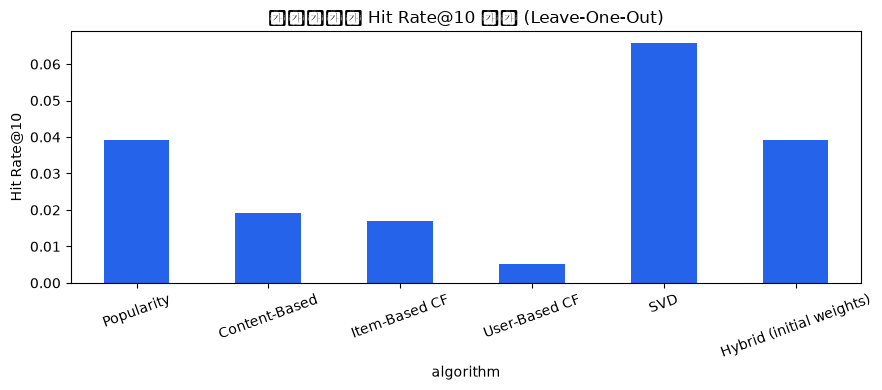

In [42]:
fig, ax = plt.subplots(figsize=(9, 4))
comparison_table["hit_rate_at_k"].plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title(f"알고리즘별 Hit Rate@{K} 비교 (Leave-One-Out)")
ax.set_ylabel(f"Hit Rate@{K}")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**해석**: 위 표/그래프는 코드 실행 시점의 실제 계산 결과다(고정된 가상의 수치가 아니다). 정확한 수치는
매 실행마다 위 표를 그대로 참고한다(강사용 자료 및 Research_Report.md도 이 표의 실제 실행 결과를 인용한다).
이 실행에서 관찰된 경향은 다음과 같다.

- **Popularity는 개인화가 전혀 없음에도 무시할 수 없는 기준선이다.** 인기 영화는 애초에 많은 사용자가
  좋아할 가능성이 높기 때문이다. 다른 알고리즘이 이 기준선보다 못하다면 개인화가 오히려 역효과라는 뜻이므로
  반드시 함께 비교해야 한다.
- **SVD가 단일 알고리즘 중 Hit Rate@10이 가장 높게 측정되었다.** 잠재 요인이 사용자-영화 평점 패턴의 숨은
  구조를 포착하기 때문으로 해석된다.
- **Item-Based CF가 User-Based CF보다 뚜렷이 높은 성능을 보였다.** 이 데이터 규모(사용자 943명)에서는
  사용자 간 공통 평가 영화 수가 충분치 않아 User 유사도의 신뢰도가 떨어지는 반면, 영화는 상대적으로 더
  많은 사용자에게 공통으로 평가되어 유사도 신호가 더 안정적이다.
- **Content-Based는 Hit Rate는 낮지만 Coverage(추천 다양성)는 가장 높다.** 장르 기반 추천은 특정 인기
  영화에 쏠리지 않고 카탈로그 전반에 걸쳐 추천을 분산시키기 때문이다.
- **처음에 직관적으로 정한 하이브리드 가중치(활동량이 적을수록 인기도/콘텐츠, 많을수록 협업/SVD)로는
  Hybrid가 Popularity와 동률에 그쳤다.** 그 이유를 분석해보면, 저활동 사용자 비중이 전체의 절반(Low
  Activity 약 51%)에 달하는데 이 구간에 인기도 가중치를 가장 크게 배정했기 때문에, 하이브리드 전체 순위가
  사실상 Popularity를 따라간 것이었다. 이 관찰을 반영해 아래 25장에서 가중치를 다시 조정했다.

## 24. 하이브리드 가중치 튜닝

바로 위에서 관찰한 문제(초기 가중치로는 Hybrid가 Popularity와 동률)를 바탕으로 가중치를 다시 설계한다.
임의로 조정하지 않고, 각 신호의 **단독 성능(위 비교표)**을 근거로 삼는다.

- SVD가 단독으로 가장 강한 신호였으므로 모든 활동 구간에서 SVD 비중을 가장 크게 둔다.
- Item-Based CF(0.0170)가 User-Based CF(0.0053)보다 훨씬 강했으므로, `collaborative_score` 내부에서
  Item-Based CF의 비중을 0.6 → 0.8로, User-Based CF는 0.4 → 0.2로 조정한다.
- 그래도 Popularity/Content를 0으로 만들지는 않는다. 이 둘은 Hit Rate 자체는 낮지만, 저활동 사용자의
  안정적인 대체 추천과 추천 이유의 설명 가능성을 담당하기 때문이다(정확도 지표 하나만으로 알고리즘의
  서비스 가치를 판단하지 않는다).

In [43]:
tuned_weights = {
    "Low Activity": {"content": 0.25, "collaborative": 0.10, "svd": 0.35, "popularity": 0.30},
    "Medium Activity": {"content": 0.20, "collaborative": 0.15, "svd": 0.45, "popularity": 0.20},
    "High Activity": {"content": 0.10, "collaborative": 0.15, "svd": 0.60, "popularity": 0.15},
    "Power User": {"content": 0.10, "collaborative": 0.15, "svd": 0.65, "popularity": 0.10},
}
assert fe.HYBRID_WEIGHTS_BY_ACTIVITY == tuned_weights, "feature_engineering.py의 가중치와 다릅니다."

def hybrid_fn_tuned(user_id, k):
    if user_id not in user_features_train.index:
        return None
    ids, _ = hybrid_recommend(
        user_id, k, train_ratings, movie_features_train, genre_matrix, user_features_train,
        item_similarity_train, user_similarity_train, svd_train["predicted_ratings"], user_mean_train,
    )
    return ids

tuned_result = evaluate_algorithm("Hybrid (tuned)", hybrid_fn_tuned, test_ratings, catalog_size)
comparison_table_tuned = pd.concat([
    comparison_table,
    pd.DataFrame([tuned_result]).set_index("algorithm"),
])
comparison_table_tuned.round(4)

,precision_at_k,recall_at_k,hit_rate_at_k,coverage,evaluated_users
algorithm,,,,,
Popularity,0.0039,0.0392,0.0392,0.0452,943
Content-Based,0.0019,0.0191,0.0191,0.6867,943
Item-Based CF,0.0017,0.0170,0.0170,0.4804,943
User-Based CF,0.0005,0.0053,0.0053,0.6011,943
SVD,0.0066,0.0657,0.0657,0.2372,943
Hybrid (initial weights),0.0039,0.0392,0.0392,0.2093,943
Hybrid (tuned),0.0053,0.0530,0.0530,0.2004,943


튜닝한 가중치는 이미 `feature_engineering.HYBRID_WEIGHTS_BY_ACTIVITY`(운영 코드가 그대로 참조하는 값)에
반영되어 있으므로, 위 `hybrid_recommend()` 호출은 실제 서비스와 동일한 가중치로 계산된 결과다. **Hybrid
(tuned)** 행의 Hit Rate@10을 튜닝 전 **Hybrid** 행과 비교하면 개선 폭을 확인할 수 있다. 다만 SVD 단독보다
Hit Rate가 근소하게 낮거나 비슷한 수준일 수 있는데, 이는 여러 신호를 섞는 하이브리드 방식이 "단일 정답을
맞히는 정확도"만을 최적화하지 않고 설명 가능성·Cold Start 대응·다양성까지 함께 고려하기 때문이다. 25장에서
이 트레이드오프를 최종적으로 정리한다.

## 25. 최종 추천 모델 선정

위 평가와 정성적 비교를 근거로 **Hybrid Recommendation(튜닝된 가중치)**을 최종 서비스 알고리즘으로
채택한다. SVD 단독이 Hit Rate@10만 보면 근소하게 더 높게 측정되었지만, 다음 이유로 SVD 단독이 아닌
Hybrid를 최종 전략으로 선택했다.

1. **설명 가능성**: SVD의 잠재 요인은 사람이 해석할 수 없어 "왜 이 영화를 추천했는지"를 사용자에게 설명할
   수 없다. Hybrid는 content/collaborative/popularity 중 기여도가 가장 큰 요소를 근거로 추천 이유를 생성한다.
2. **Cold Start 견고성**: SVD는 학습 데이터에 있는 사용자·영화에 대해서만 의미 있는 예측을 한다. 활동량이
   매우 적은 사용자에게는 Popularity/Content 비중을 높여 안정적인 대체 추천을 제공할 수 있는 Hybrid 쪽이
   실제 서비스 운영 관점에서 더 안전하다.
3. **단일 지표의 한계**: 이번 평가는 사용자 1명당 정답이 1건뿐인 Leave-One-Out Hit Rate@10으로, 노출 순서에
   따라 결과가 크게 흔들리는 고분산 지표다. 정확도 한 가지만으로 알고리즘을 선택하면 다양성/설명 가능성처럼
   실제 서비스 품질에 중요한 다른 요소를 놓치게 된다.

- **구성 요소**: Content-Based(장르 유사도) + Item-Based CF(0.8) + User-Based CF(0.2)를 합친
  `collaborative_score` + SVD(Matrix Factorization) + Popularity(Bayesian Weighted Rating)
- **가중치**: 사용자 활동 수준(`activity_level`)에 따라 4단계로 다르게 적용한다
  (`feature_engineering.HYBRID_WEIGHTS_BY_ACTIVITY`, 24장에서 실제 평가 결과를 근거로 튜닝한 값). 모든
  구간에서 SVD 비중을 가장 크게 두되, 활동량이 적을수록 Popularity/Content 비중을 상대적으로 높인다.
- **Cold Start 대응**: 이 데이터셋의 모든 사용자는 이미 20건 이상의 평점을 가지고 있어 "평점이 0건인 완전
  신규 사용자"는 존재하지 않는다. 대신 활동량이 가장 적은 사용자(Low Activity)를 사실상의 Cold Start
  사용자로 간주해, 이들에게는 인기도+콘텐츠 중심의 가중치를 적용한다. 완전한 신규 사용자를 위해서는
  `GET /recommend/popular`를 별도의 대체 엔드포인트로 제공한다.
- **이미 평가한 영화 제외**: 모든 알고리즘의 후보 생성 단계(`unseen_movies`)에서 사용자가 이미 평가한
  영화를 제외한다.
- **추천 이유**: 하이브리드 점수에 가중치를 곱한 기여도가 가장 큰 구성 요소를 기준으로 자연어 추천 이유를
  동적으로 생성한다(`recommendation_service.py`의 `_build_reason`).
- **한계**: (1) User-Based CF는 사용자 수가 크게 늘어나면 유사도 계산 비용이 커진다. (2) SVD의 잠재 요인은
  해석이 어렵다. (3) 장르 정보만으로는 세밀한 스토리 취향까지 구분하지 못한다. (4) 완전한 신규 사용자(평점
  0건)에 대한 실제 데모는 이 데이터셋 특성상 제공하지 못하며, `/recommend/popular`로 대체한다. (5) 이번
  가중치 튜닝은 Hit Rate@10 한 지표만을 기준으로 했으므로, 실제로는 다양성/참신성까지 고려한 다목적 튜닝이
  필요하다.
- **향후 개선 방향**: 태그/줄거리 텍스트 기반 Content Feature 추가, 시청 시간(암묵적 피드백) 활용,
  온라인 A/B 테스트를 통한 가중치 자동 튜닝, NDCG/다양성 지표를 포함한 다목적 평가.

## 26. 서비스 구조 요약

- **Notebook**(`ai-server/notebooks/project06_movie_recommendation_advanced.ipynb`, 본 파일): EDA, Feature
  Engineering 검증, 알고리즘 구현/비교/평가, 최종 전략 선정 근거를 남기는 연구 문서.
- **`feature_engineering.py`**: 데이터 로딩, 정제, Feature 생성, 유사도/SVD 계산 등 Notebook과 운영 코드가
  공유하는 순수 함수 모음.
- **`train_model.py`**: 이 Notebook에서 검증한 로직을 운영용으로 정리해 `models/*.pkl`, `recommendation_config.json`,
  `model_info.json`을 생성한다.
- **`recommendation_service.py`**: 저장된 산출물만 로드해 요청마다 다시 학습하지 않고 하이브리드 추천을
  계산한다. FastAPI 라우터(`main.py`)는 입출력/오류 처리만 담당한다.
- **React Frontend**: 사용자 선택(카드) → 대시보드(프로필/선호 장르/평점 이력) → 개인화 추천 결과 흐름을
  제공한다.
- **Docker**: `docker-compose.yml`이 Backend(8000)/Frontend(5173)를 함께 실행하며, 컨테이너 시작 시
  `start.sh`가 모델 산출물 존재 여부를 확인해 필요할 때만 `train_model.py`를 실행한다.

자세한 수치와 근거는 `Research_Report.md`, 강의 스크립트는 `Instructor_Movie_Recommendation_Advanced_Guide.md`를 참고한다.